# 18 Сортирање, филтрирање и фреквенцијска анализа

Сортирање података служи да бисмо податке поређали по величини по којој желимо да их упорећујемо. За приказивање сортирања користићемо следећу табелу:

### 18.1 Сортирање

In [1]:
import pandas as pd
ученици=[["Алекса Алексић",       "1а",4.82,34,2],
         ["Бранко Бранковић",     "2д",4.33,98,1],
         ["Владимир Владимировић","3ц",5.00,55,0],
         ["Гаврило Гавриловић",   "2б",4.56,11,0],
         ["Дејана Дејанић",       "1е",4.86,21,0],
         ["Ђурђа Ђурђевић",       "4а",4.92,44,6],
         ["Ерик Ериксон",         "3б",5.00,32,8],
         ["Жика Жикић",           "4д",4.77,36,1],
         ["Здравко Здравковић",   "1д",4.88,35,0],
         ["Иван Ивановић",        "3е",4.88,67,0],
         ["Јована Јовановић",     "2ц",4.82,88,1],
         ["Коста Костић",         "1б",4.50,37,2]]
табела=pd.DataFrame(ученици)
табела.columns=["име и презиме", "одељење", "просек", "оправдани", "неоправдани"]
нова_табела=табела.set_index("име и презиме")
нова_табела

,одељење,просек,оправдани,неоправдани
име и презиме,,,,
Алекса Алексић,1а,4.82,34,2
Бранко Бранковић,2д,4.33,98,1
Владимир Владимировић,3ц,5.00,55,0
Гаврило Гавриловић,2б,4.56,11,0
Дејана Дејанић,1е,4.86,21,0
Ђурђа Ђурђевић,4а,4.92,44,6
Ерик Ериксон,3б,5.00,32,8
Жика Жикић,4д,4.77,36,1
Здравко Здравковић,1д,4.88,35,0


Сада ћемо сортирати податке према броју оправданих изостанака:

In [2]:
сортирана_табела=нова_табела.sort_values(by="оправдани")
сортирана_табела

,одељење,просек,оправдани,неоправдани
име и презиме,,,,
Гаврило Гавриловић,2б,4.56,11,0
Дејана Дејанић,1е,4.86,21,0
Ерик Ериксон,3б,5.00,32,8
Алекса Алексић,1а,4.82,34,2
Здравко Здравковић,1д,4.88,35,0
Жика Жикић,4д,4.77,36,1
Коста Костић,1б,4.50,37,2
Ђурђа Ђурђевић,4а,4.92,44,6
Владимир Владимировић,3ц,5.00,55,0


Можемо приметити да је табела сортирана према броју оправданих изостанака растуће. Ако желимо да сортирање буде опадајуће потребно је да урадимо следеће:

In [3]:
сортирана_табела=нова_табела.sort_values(by="оправдани",ascending=False)
сортирана_табела

,одељење,просек,оправдани,неоправдани
име и презиме,,,,
Бранко Бранковић,2д,4.33,98,1
Јована Јовановић,2ц,4.82,88,1
Иван Ивановић,3е,4.88,67,0
Владимир Владимировић,3ц,5.00,55,0
Ђурђа Ђурђевић,4а,4.92,44,6
Коста Костић,1б,4.50,37,2
Жика Жикић,4д,4.77,36,1
Здравко Здравковић,1д,4.88,35,0
Алекса Алексић,1а,4.82,34,2


Сада још можемо графички да прикажемо оправдане и неоправдане изостанке.

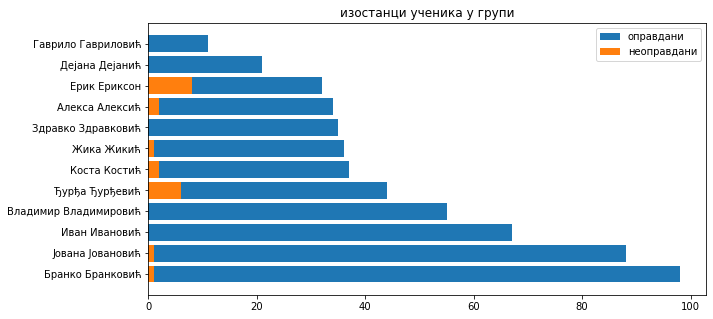

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.barh(сортирана_табела.index, сортирана_табела["оправдани"], label="оправдани")
plt.barh(сортирана_табела.index, сортирана_табела["неоправдани"], label="неоправдани")
plt.title("изостанци ученика у групи")
plt.legend()
plt.show()
plt.close()

### 18.2 Филтрирање

Филтрирање нам омогућује да одређене податке издвојимо из табеле. Хајде за почетак да издвојимо ученике са просеком 5.00:

In [5]:
пет_нула=нова_табела[нова_табела.просек ==5]
пет_нула

,одељење,просек,оправдани,неоправдани
име и презиме,,,,
Владимир Владимировић,3ц,5.0,55,0
Ерик Ериксон,3б,5.0,32,8


Сада ћемо применити више услова и филтрираћемо одличне ученике који немају неоправданих изостанака.

In [9]:
одликаши=нова_табела[(нова_табела.просек >=4.5) & (нова_табела.неоправдани==0)]
одликаши

,одељење,просек,оправдани,неоправдани
име и презиме,,,,
Владимир Владимировић,3ц,5.00,55,0
Гаврило Гавриловић,2б,4.56,11,0
Дејана Дејанић,1е,4.86,21,0
Здравко Здравковић,1д,4.88,35,0
Иван Ивановић,3е,4.88,67,0


Филтриране податке можемо графички представити:

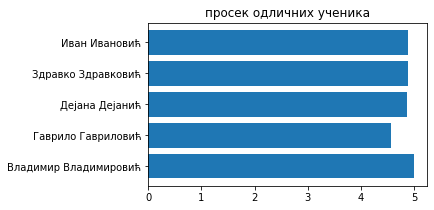

In [13]:
plt.figure(figsize=(5,3))
plt.barh(одликаши.index, одликаши["просек"])
plt.title("просек одличних ученика")
plt.show()
plt.close()

### 18.3 Фреквенцијска анализа

Фреквенцијску анализу смо већ радили за низове, а сада ћемо видети како се она ради за табеле. Посматраћемо у табели ученика колону са неоправданим изостанцима.

In [14]:
нова_табела["неоправдани"].value_counts()

0    5
1    3
2    2
8    1
6    1
Name: неоправдани, dtype: int64

Ако желимо да направимо секторски дијаграм, потребно је да ове податке сачувамо у некој променљивој.

In [15]:
фреквенција_неоправданих=нова_табела["неоправдани"].value_counts()

На следећи начин можемо приступити подацима о различитим вредностима и њиховим фреквенцијама:

In [16]:
print("Вредности неоправданих које се јављају:", фреквенција_неоправданих.index)
print("Њихове фреквенције:", фреквенција_неоправданих.values)

Вредности неоправданих које се јављају: Int64Index([0, 1, 2, 8, 6], dtype='int64')
Њихове фреквенције: [5 3 2 1 1]


Сада ћемо ове податке приказати секторским дијаграмом.

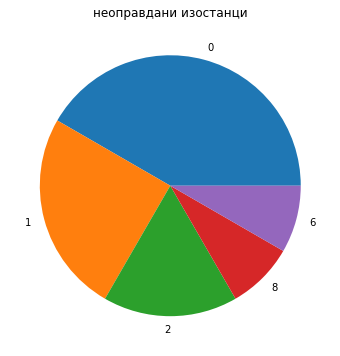

In [17]:
import matplotlib.pyplot as plt
фрекв=нова_табела["неоправдани"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(фрекв.values, labels=фрекв.index)
plt.title("неоправдани изостанци")
plt.show()
plt.close()

### 18.4 Џупитер и Ексел - за и против

Када је пред нама задатак да обрадимо податке, Ексел и Џупитер нам дају много могућности. Оба програма имају своје предности и мане и у зависности од проблема који решавамо ми ћемо изабрати одговарајући. Предност Ексела је што је опипљив и што је све интуитивно, али мана му је то што неке сложеније формуле није лако испратити. Џупитер има предност јер је бесплатан за разлику од Ексела. Такође, у Џупитеру је много лакше радити са сложенијим функцијама и формулама. Библиотеке које имамо ту омогућавају пуно различитих корисних функција.

Џупитер и Ексел су компатибилни, па тако Ексел табелу можемо убацити у Џупитер радну свеску или табелу из Џупитер радне свеске можемо сачувати у xls формату.

In [20]:
import pandas as pd
аутомобили = pd.read_excel("8-7-3.xlsx", sheet_name="Sheet1")
аутомобили

,произвођач,модел,годиште,цена
0,BMW,118d,2009,5200
1,Mercedes,E220,2013,11050
2,Audi,A3,2009,6000
3,Volvo,S60,2015,12500
4,BMW,320i,2012,11900
5,Audi,A4,2017,18300
6,BMW,525d,2008,7100
7,Volvo,XC60,2014,14300
8,Mercedes,C180,2010,9250
9,Audi,A7,2015,24500


Сада можемо видети који су произвођачи и колико често заступљени.

In [21]:
аутомобили["произвођач"].value_counts()

BMW         6
Mercedes    5
Audi        5
Volvo       4
Name: произвођач, dtype: int64

На крају ћемо издвојити само возила произвођача БМВ и сместити их у нову табелу.

In [23]:
само_бмв=аутомобили[аутомобили.произвођач == "BMW"]
само_бмв

,произвођач,модел,годиште,цена
0,BMW,118d,2009,5200
4,BMW,320i,2012,11900
6,BMW,525d,2008,7100
13,BMW,X5,2018,45900
15,BMW,X1,2011,10000
18,BMW,X2,2019,19900


In [24]:
само_бмв.to_excel("само_бмв.xlsx", encoding="utf-8")

#### Задаци

#### Задатак 1
Изнеси своја запажања о предностима и манама Ексела и Џупитера.

#### Задатак 2
За произвољних 10 престоница у Европи наћи број становника, направити и индексирати табелу и сортирати је. Након тога филтрирати све престонице чији је број становника између једог и три милиона.

#### Задатак 3
Са сајта https://www.worldometers.info/world-population/ преузети податке о броју становника у 20 најмногољуднијих земаља, направити табелу и филтрирати их тако да остану само државе са више од 100000000 а мање од 1000000000 становника.

#### Задатак 4
Са странице https://www.laliga.com/en-GB/stats преузети податке о најбољим стрелцима шпанског фудбалског првенства. Формирати табелу и сортирати је према просечном броју голова које играч постиже по мечу, а затим филтрирати податке тако да остану само играчи који постижу више од 0.5 голова по мечу.

#### Задатак 5
Учитати податке о мечевима кошаркашке репрезентације из табеле 8-6-5.xlsx и додати нове колоне које представљају кош разлику и за колико је процената већи број поена који смо дали. Након тога сортирати мечеве према кош разлици, направити филтер тако да остану само победе са више од 20% разлике и све то вратити као нови Ексел фајл.

#### Задатак 6
Са сајта https://www.aba-liga.com/standings/20/1/ учитати табелу Јадранске кошаркашке лиге. Након тога сортирати тимове према кош разлици и направити филтер који издваја тимове са позитивном кош разликом. Податке о тим тимовима сачувати у Ексел табели,